In [2]:
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [3]:
word_embeddings = {
    "cat":[0.8,0.6],
    "kitten":[0.75,0.65],
    "puppy":[0.65,0.35],
    "car":[-0.5,0.1],
    "truck":[0.45,0.15]
}

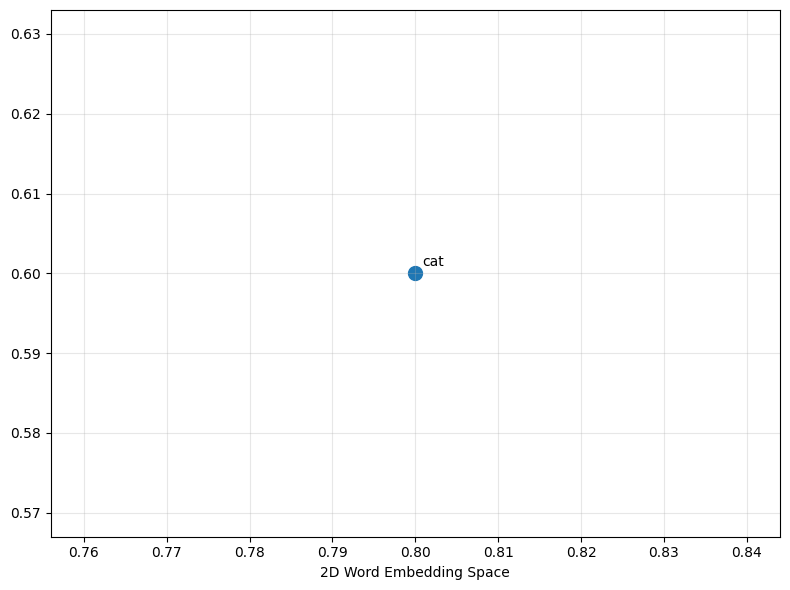

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [5]:
figure,axis = plt.subplots(figsize=(8,6))


for word,coords in word_embeddings.items():
    axis.scatter(coords[0],coords[1], s=100)
    axis.annotate(word, (coords[0],coords[1]), xytext=(5,5), 
                  textcoords='offset points')
    
    axis.set_xlabel('Dim 1')
    axis.set_xlabel('Dim 2')
    axis.set_xlabel('2D Word Embedding Space')
    axis.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    

In [8]:
##Measuring Cosing Similarity between vectors

def cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1,vec2)
    mag_1= np.linalg.norm(vec1)
    mag_2= np.linalg.norm(vec2)
    
    return dot_product/(mag_1*mag_2)

car=[-0.5,0.1],
truck=[-0.45,0.15]

#Cosine Similarity for pairs
car_truck_similarity = cosine_similarity(car,truck)
print(car_truck_similarity)
    

[0.99227788]


In [9]:
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name = "sentence-transformers/all-MiniLM-L6-v2"
)

embeddings

/Users/hamza/Downloads/RAG/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [10]:
text="Hi, My name is Hamza, I'm a Gen AI Developer"

embedding = embeddings.embed_query(text)
print(f"Text: {len(embedding)}")
print(embedding)

Text: 384
[-0.06788909435272217, -0.028110669925808907, -0.005851436406373978, -0.003636918030679226, -0.035223547369241714, -0.08948250859975815, 0.09005307406187057, 0.0426291897892952, -0.023247569799423218, -0.05742291361093521, -0.07231975346803665, -0.09831930696964264, 0.016123013570904732, -0.01208732184022665, 0.00764621514827013, 0.038330912590026855, -0.026435086503624916, -0.004614752251654863, -0.07007124274969101, -0.08224165439605713, -0.0246373750269413, 0.006139098200947046, -8.728057582629845e-05, -0.06137891858816147, -0.022215433418750763, 0.009417230263352394, 0.03704967722296715, 0.08061669766902924, 0.04872805252671242, -0.04332129284739494, 0.009205162525177002, 0.05944841727614403, 0.09439798444509506, 0.05723853409290314, 0.04141348600387573, 0.0861315205693245, -0.028117258101701736, -0.04419747740030289, 0.04054078459739685, -0.06177344545722008, 0.01150943897664547, 0.007136797532439232, -0.019620662555098534, -0.020212970674037933, 0.07930044084787369, -0.

In [14]:
sentences = [
    "Hi, My name is Hamza, I'm a Gen AI Developer",
    "I've got 4 years of experience wokring as a full stack software dev",
    "Probelm solving is my core skill"
]

embedding_sentences = embeddings.embed_documents(sentences)
print(embedding_sentences)

[[-0.06788907945156097, -0.02811068296432495, -0.005851434543728828, -0.003636885667219758, -0.035223525017499924, -0.08948250859975815, 0.09005303680896759, 0.042629193514585495, -0.02324756607413292, -0.057422950863838196, -0.07231971621513367, -0.09831936657428741, 0.01612299308180809, -0.012087269686162472, 0.007646248675882816, 0.038330886512994766, -0.02643512561917305, -0.004614786710590124, -0.0700712725520134, -0.08224165439605713, -0.02463741973042488, 0.006139117293059826, -8.728343527764082e-05, -0.061378948390483856, -0.02221541851758957, 0.009417233057320118, 0.037049680948257446, 0.08061666041612625, 0.048728056252002716, -0.043321315199136734, 0.0092051662504673, 0.05944840610027313, 0.09439795464277267, 0.05723855644464493, 0.04141349345445633, 0.0861315131187439, -0.028117291629314423, -0.044197503477334976, 0.040540825575590134, -0.061773378401994705, 0.011509433388710022, 0.007136847358196974, -0.019620677456259727, -0.020212935283780098, 0.07930044829845428, -0.007

OpenAI Embeddings

In [15]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [19]:
os.environ["OPENAI_API_KEY"]= os.getenv("OPENAI_API_KEY")

In [22]:
from langchain_openai import OpenAIEmbeddings
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
embeddings

OpenAIEmbeddings(client=<openai.resources.embeddings.Embeddings object at 0x3046b9090>, async_client=<openai.resources.embeddings.AsyncEmbeddings object at 0x3046b9a90>, model='text-embedding-3-small', dimensions=None, deployment='text-embedding-ada-002', openai_api_version=None, openai_api_base=None, openai_api_type=None, openai_proxy=None, embedding_ctx_length=8191, openai_api_key=SecretStr('**********'), openai_organization=None, allowed_special=None, disallowed_special=None, chunk_size=1000, max_retries=2, request_timeout=None, headers=None, tiktoken_enabled=True, tiktoken_model_name=None, show_progress_bar=False, model_kwargs={}, skip_empty=False, default_headers=None, default_query=None, retry_min_seconds=4, retry_max_seconds=20, http_client=None, http_async_client=None, check_embedding_ctx_length=True)

In [24]:
#Single Text Embeddings
single_text = "GEN AI is an amazing skill"
single_embeddigns = embeddings.embed_query(single_text)
print("Single Text Embedding:", single_embeddigns)
print(f"Input :{single_text} | Embedding Length: {len(single_embeddigns)}")


RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

In [25]:
multiple_embeddings = embeddings.embed_documents(sentences)
multiple_embeddings

RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

In [ ]:
#Caclulate the similarity between all pairs


for i in range(len(sentences)):
    for j in range(i+1,len(sentences)):
        similarity = cosine_similarity(embedding_sentences[i],embedding_sentences[j])
        
        print(f"'{sentences[i]}' vs '{sentences[j]}'")
        print(f"Similarity: {similarity: }\n")
        

Semantic Vector Search

In [26]:
documents = [
    "Learning new skills is must to stay relevant today",
    "London is the best place to live",
    "Wales has best sceneries",
    "Gen AI is most important skill today in software domain"
]

query="Most in demand skill these days"

In [27]:
def semantic_search(query,documents,embeddings_models,top_k=3):
    "Simple semantic search"
    
    query_embeddings= embeddings_models.embed_query(query)
    doc_embeddings= embeddings_models.embed_documents(documents)
    
    ## Similarity score
    
    similarities = []
    
    for i,doc_emb in enumerate(doc_embeddings):
        similarity = cosine_similarity(query_embeddings,doc_emb)
        similarities.append(similarity,documents[i])
        
        
    ## sorting by similarities
    similarities.sort(reverse=True)
    return similarities[:top_k]

        
    

In [29]:
results = semantic_search(query,documents,embeddings)

type(results)


RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}